<a href="https://colab.research.google.com/github/Jiya936/AI_mse2/blob/main/Interior_Designer_AI_Gemini_shrt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏠 AI-Powered Interior Designer (Gemini + Imagen)
> Upload a room photo → get AI design suggestions + redesigned room image

**Powered by Google Gemini API (FREE tier available!)**

**Flow:**
1. 🔑 Enter your free Gemini API key
2. 📸 Upload a room image
3. 🧠 Gemini Vision analyzes your room
4. 🪑 Get furniture, layout & color suggestions
5. 🎨 Generate a redesigned room image
6. 📤 Export results as JSON

---

## 📦 Cell 1 — Install Dependencies

In [1]:
# Install required libraries
!pip install google-generativeai pillow requests matplotlib --quiet
print("✅ All dependencies installed!")

✅ All dependencies installed!


## 🔑 Cell 2 — Set Your Gemini API Key

> **Get a FREE key at:** https://aistudio.google.com/app/apikey
> No credit card needed!
>
> ⚠️ Never paste your key directly in code — use the secure input below.

In [2]:
import os
from getpass import getpass

# Securely prompt for API key (input is hidden like a password)
api_key = getpass("🔑 Enter your Gemini API Key: ")
os.environ["GEMINI_API_KEY"] = api_key

print("✅ Gemini API key set securely!")

🔑 Enter your Gemini API Key: ··········
✅ Gemini API key set securely!


## 📚 Cell 3 — Import Libraries & Initialize Gemini

In [8]:
import os
import json
import requests
import base64
from io import BytesIO
from getpass import getpass

import google.generativeai as genai
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Configure Gemini with your API key
genai.configure(api_key=os.environ.get("GEMINI_API_KEY"))

# ✅ Updated model name — gemini-2.5-flash (replaces deprecated 1.5-flash)
model = genai.GenerativeModel("gemini-2.5-flash")

print("✅ Gemini 2.5 Flash model loaded!")
print("   Model: gemini-2.5-flash (Vision + Text, FREE tier)")

✅ Gemini 2.5 Flash model loaded!
   Model: gemini-2.5-flash (Vision + Text, FREE tier)


## 📸 Cell 4 — Upload Your Room Image
> Run **Option A** (file upload) OR **Option B** (URL). Not both.

In [9]:
# ==============================
# OPTION A: Upload from your computer
# ==============================
from google.colab import files

print("📂 Please upload a room image (JPG, PNG, WEBP)...")
uploaded = files.upload()

if uploaded:
    image_filename = list(uploaded.keys())[0]
    image_source = "upload"
    print(f"✅ Uploaded: {image_filename}")
else:
    print("❌ No file uploaded. Try Option B below.")

📂 Please upload a room image (JPG, PNG, WEBP)...


Saving pexels-hiroom-17181935.jpg to pexels-hiroom-17181935 (1).jpg
✅ Uploaded: pexels-hiroom-17181935 (1).jpg


In [5]:
# ==============================
# OPTION B: Use an image URL instead
# ==============================
# Uncomment the lines below if you want to use a URL

# image_url_input = "https://example.com/your-room.jpg"  # <-- paste your URL here
# image_source = "url"
# print(f"✅ Image URL set: {image_url_input}")

## 🔧 Cell 5 — Helper Functions

In [10]:
def load_pil_image(source_type, filename=None, url=None):
    """
    Loads image as a PIL Image object.
    Works from uploaded file or from a URL.
    """
    if source_type == "upload":
        return Image.open(filename).convert("RGB")
    elif source_type == "url":
        response = requests.get(url, timeout=15)
        response.raise_for_status()
        return Image.open(BytesIO(response.content)).convert("RGB")
    else:
        raise ValueError("source_type must be 'upload' or 'url'")


def generate_room_image_stability(prompt, api_key):
    """
    Generates a room image using Stability AI's free API.
    Returns a PIL Image or None if it fails.
    """
    try:
        url = "https://api.stability.ai/v1/generation/stable-diffusion-xl-1024-v1-0/text-to-image"
        headers = {
            "Authorization": f"Bearer {api_key}",
            "Content-Type": "application/json",
            "Accept": "application/json"
        }
        body = {
            "text_prompts": [{"text": prompt, "weight": 1}],
            "cfg_scale": 7,
            "height": 768,
            "width": 1344,
            "steps": 30,
            "samples": 1
        }
        response = requests.post(url, headers=headers, json=body)
        response.raise_for_status()
        data = response.json()
        img_b64 = data["artifacts"][0]["base64"]
        return Image.open(BytesIO(base64.b64decode(img_b64)))
    except Exception as e:
        print(f"⚠️ Stability AI generation failed: {e}")
        return None


def display_images_side_by_side(original_img, generated_img, theme="Modern Style"):
    """
    Shows original and redesigned room images side by side.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    axes[0].imshow(original_img)
    axes[0].set_title("📷 Your Original Room", fontsize=14, fontweight="bold", pad=12)
    axes[0].axis("off")

    if generated_img:
        axes[1].imshow(generated_img)
        axes[1].set_title(f"✨ AI Redesign — {theme}", fontsize=14, fontweight="bold", pad=12)
    else:
        axes[1].text(0.5, 0.5,
                     "Image generation skipped.\nSee suggestions above!",
                     ha="center", va="center", fontsize=12,
                     color="#555555", wrap=True)
        axes[1].set_facecolor("#f5f5f5")
        axes[1].set_title("✨ AI Redesign", fontsize=14, fontweight="bold", pad=12)
    axes[1].axis("off")

    plt.suptitle("🏠 AI Interior Designer — Before & After",
                 fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


def display_color_palette(hex_colors):
    """
    Renders a visual color palette from HEX codes.
    """
    if not hex_colors:
        print("No color palette available.")
        return

    # Clean hex codes (ensure they start with #)
    cleaned = [c if c.startswith("#") else f"#{c}" for c in hex_colors]

    fig, ax = plt.subplots(figsize=(len(cleaned) * 2.2, 2.2))
    for i, color in enumerate(cleaned):
        try:
            rect = mpatches.FancyBboxPatch(
                (i * 1.1, 0), 1.0, 1.0,
                boxstyle="round,pad=0.05",
                linewidth=1.5, edgecolor="#dddddd",
                facecolor=color
            )
            ax.add_patch(rect)
            ax.text(i * 1.1 + 0.5, -0.18, color,
                    ha="center", va="top", fontsize=9, color="#444444")
        except Exception:
            pass  # Skip invalid hex codes

    ax.set_xlim(-0.1, len(cleaned) * 1.1)
    ax.set_ylim(-0.4, 1.2)
    ax.axis("off")
    ax.set_title("🎨 Recommended Color Palette", fontsize=13, fontweight="bold", pad=10)
    plt.tight_layout()
    plt.show()


print("✅ Helper functions ready!")

✅ Helper functions ready!


## 🧠 Cell 6 — Analyze Room with Gemini Vision

In [11]:
print("🔍 Loading image...")

try:
    if image_source == "upload":
        original_pil = load_pil_image("upload", filename=image_filename)
    else:
        original_pil = load_pil_image("url", url=image_url_input)

    print(f"✅ Image loaded! Size: {original_pil.size[0]}×{original_pil.size[1]} px")

except Exception as e:
    print(f"❌ Failed to load image: {e}")
    raise

# --- Analysis prompt for Gemini ---
analysis_prompt = """
You are an expert interior designer. Analyze this room image carefully.

Respond ONLY with a valid JSON object. No markdown, no extra text, no code fences.

Use exactly this structure:
{
  "room_type": "e.g. Living Room, Bedroom, Kitchen",
  "existing_furniture": ["item1", "item2"],
  "empty_spaces": ["area1", "area2"],
  "lighting_conditions": "description of lighting",
  "furniture_suggestions": ["suggestion1", "suggestion2"],
  "decor_suggestions": ["decor1", "decor2"],
  "layout_improvements": ["improvement1", "improvement2"],
  "design_theme": "e.g. Scandinavian Minimalist, Bohemian, Industrial",
  "color_palette": ["#HEX1", "#HEX2", "#HEX3", "#HEX4", "#HEX5"]
}
"""

# --- Send image + prompt to Gemini ---
print("\n🤖 Sending to Gemini Vision for analysis...")

try:
    response = model.generate_content([analysis_prompt, original_pil])
    raw_text = response.text.strip()

    # Strip markdown fences if Gemini adds them
    if "```" in raw_text:
        raw_text = raw_text.split("```")[1]
        if raw_text.startswith("json"):
            raw_text = raw_text[4:].strip()

    design_data = json.loads(raw_text)
    print("✅ Room analysis complete and parsed successfully!")

except json.JSONDecodeError:
    print(f"⚠️ JSON parse error. Raw response:\n{raw_text}")
    raise
except Exception as e:
    print(f"❌ Gemini API error: {e}")
    raise

🔍 Loading image...
✅ Image loaded! Size: 5472×3648 px

🤖 Sending to Gemini Vision for analysis...


ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 15856.62ms


✅ Room analysis complete and parsed successfully!


## 🪑 Cell 7 — Display Design Suggestions

🏠 ROOM ANALYSIS & DESIGN SUGGESTIONS

📐 Room Type        : Bedroom
💡 Lighting         : Abundant natural light from a large triple-pane window with a beautiful mountain view. A single recessed ceiling light provides artificial illumination. The mirrored closet doors further reflect and distribute light.
🎨 Suggested Theme  : Modern Rustic / Mountain Modern

🛋️  Existing Furniture:
   • Built-in window seat/ledge
   • Mirrored sliding closet doors
   • Baseboard heaters

📦 Empty / Underused Spaces:
   • Main floor area
   • Wall space opposite the window
   • Wall space adjacent to the entry door

✨ Furniture Suggestions:
   ➕ Queen or King size bed
   ➕ Two nightstands with lamps
   ➕ Area rug (large to define sleeping zone)
   ➕ Dresser or chest of drawers (potentially on the wall opposite the closet)
   ➕ A comfortable accent chair and small side table next to the window seat

🖼️  Decor Suggestions:
   🎍 Curtains or blinds for the window (e.g., woven wood or linen)
   🎍 Wall art above

/tmp/ipykernel_17519/294239114.py:104: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


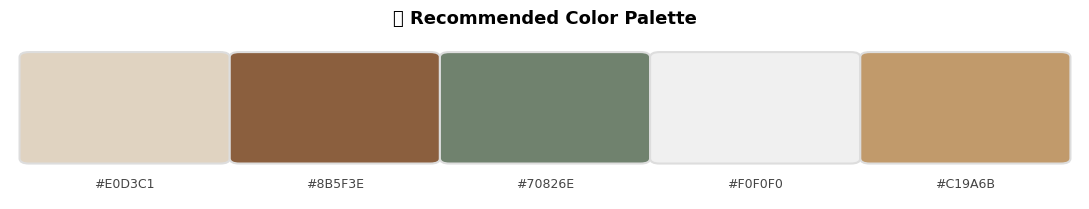

In [12]:
print("=" * 60)
print("🏠 ROOM ANALYSIS & DESIGN SUGGESTIONS")
print("=" * 60)

print(f"\n📐 Room Type        : {design_data.get('room_type', 'N/A')}")
print(f"💡 Lighting         : {design_data.get('lighting_conditions', 'N/A')}")
print(f"🎨 Suggested Theme  : {design_data.get('design_theme', 'N/A')}")

print("\n🛋️  Existing Furniture:")
for item in design_data.get("existing_furniture", []):
    print(f"   • {item}")

print("\n📦 Empty / Underused Spaces:")
for space in design_data.get("empty_spaces", []):
    print(f"   • {space}")

print("\n✨ Furniture Suggestions:")
for s in design_data.get("furniture_suggestions", []):
    print(f"   ➕ {s}")

print("\n🖼️  Decor Suggestions:")
for d in design_data.get("decor_suggestions", []):
    print(f"   🎍 {d}")

print("\n📏 Layout Improvements:")
for l in design_data.get("layout_improvements", []):
    print(f"   🔧 {l}")

print("\n🎨 Color Palette:")
for c in design_data.get("color_palette", []):
    print(f"   🟦 {c}")

print("\n" + "=" * 60)

# Visual color palette
display_color_palette(design_data.get("color_palette", []))

## 🎨 Cell 8 — Generate Redesigned Room Image

> This uses **Stability AI** (free credits on sign-up) to generate the redesigned room.
>
> **Get a free Stability AI key at:** https://platform.stability.ai
>
> If you skip this, Cell 9 will still show your original image + suggestions.

In [13]:
# --- Build dynamic image generation prompt from Gemini's analysis ---
furniture_list = ", ".join(design_data.get("furniture_suggestions", ["modern sofa", "coffee table"])[:4])
color_list     = ", ".join(design_data.get("color_palette", ["#FFFFFF"])[:3])
theme          = design_data.get("design_theme", "modern minimalist")
room_type      = design_data.get("room_type", "living room")
layout_tip     = (design_data.get("layout_improvements") or [""])[0]

dalle_style_prompt = (
    f"Professional interior design photo of a beautifully redesigned {room_type} "
    f"in {theme} style. Include: {furniture_list}. "
    f"Color palette inspired by: {color_list}. "
    f"{layout_tip} "
    f"Realistic natural lighting, ultra-detailed, architectural digest quality, "
    f"high resolution, no people, photorealistic."
)

print("📝 Image Generation Prompt:")
print(f"   {dalle_style_prompt[:220]}...")

# --- Option 1: Use Stability AI (free credits) ---
stability_key = getpass("\n🔑 Enter your Stability AI key (or press Enter to skip image gen): ")

generated_img = None

if stability_key.strip():
    print("\n⏳ Generating redesigned room... (15–30 seconds)")
    generated_img = generate_room_image_stability(dalle_style_prompt, stability_key.strip())
    if generated_img:
        design_data["generated_image_url"] = "[Saved as PIL Image - see Cell 9]"
        print("✅ Room image generated successfully!")
    else:
        print("⚠️ Generation failed. Proceeding without redesigned image.")
else:
    print("⏭️ Image generation skipped. Showing suggestions only.")
    design_data["generated_image_url"] = "skipped"

📝 Image Generation Prompt:
   Professional interior design photo of a beautifully redesigned Bedroom in Modern Rustic / Mountain Modern style. Include: Queen or King size bed, Two nightstands with lamps, Area rug (large to define sleeping zone), Dres...

🔑 Enter your Stability AI key (or press Enter to skip image gen): ··········

⏳ Generating redesigned room... (15–30 seconds)
✅ Room image generated successfully!


## 🖼️ Cell 9 — Display Before & After

/tmp/ipykernel_17519/294239114.py:70: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17519/294239114.py:70: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17519/294239114.py:70: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


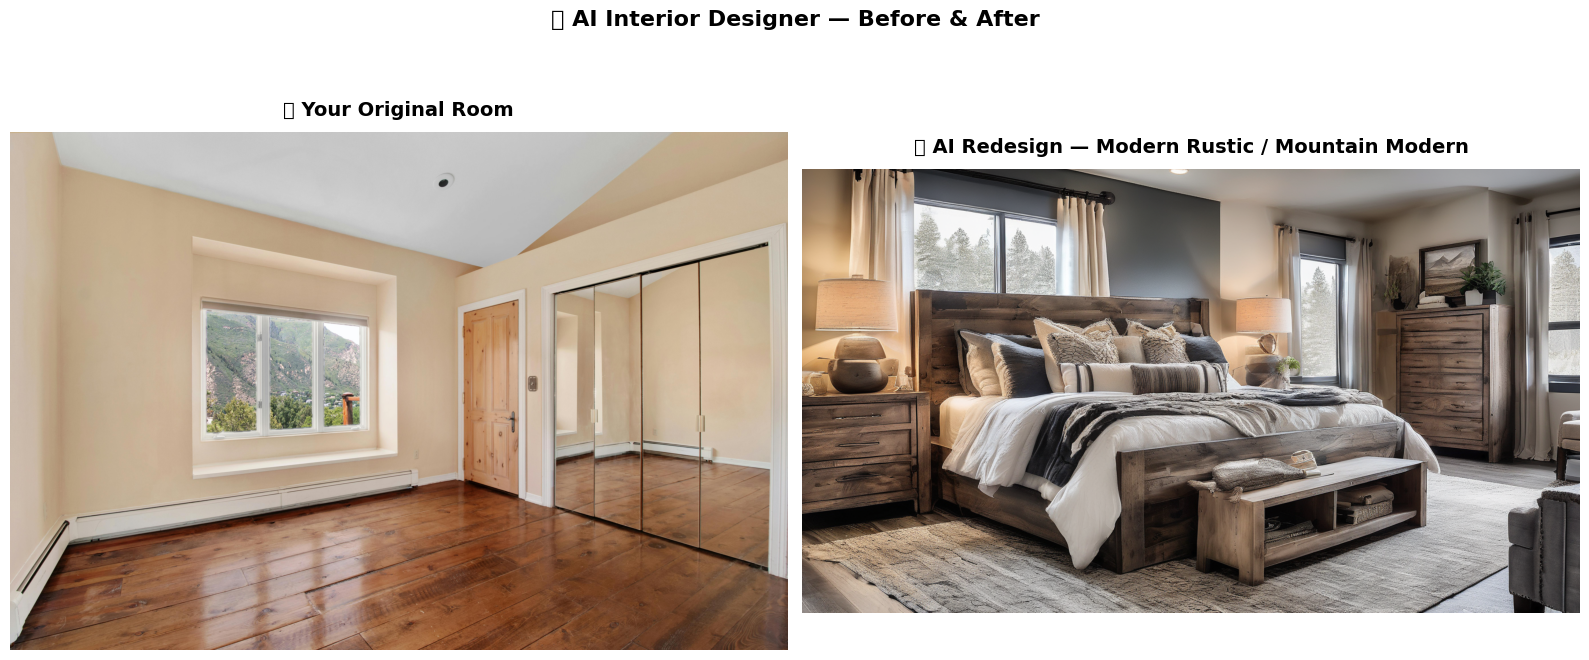

✅ Comparison displayed!


In [14]:
# Display side-by-side comparison
display_images_side_by_side(
    original_img=original_pil,
    generated_img=generated_img,  # None if skipped
    theme=design_data.get("design_theme", "Modern Style")
)

print("✅ Comparison displayed!")

## 📤 Cell 10 — Export Structured JSON Output

In [15]:
output_filename = "interior_design_output.json"

# Save JSON file
with open(output_filename, "w") as f:
    json.dump(design_data, f, indent=2)

# Print structured output
print("📁 Structured JSON Output:")
print(json.dumps(design_data, indent=2))

# Download to your computer
from google.colab import files
files.download(output_filename)
print(f"\n✅ Saved and downloaded: {output_filename}")

📁 Structured JSON Output:
{
  "room_type": "Bedroom",
  "existing_furniture": [
    "Built-in window seat/ledge",
    "Mirrored sliding closet doors",
    "Baseboard heaters"
  ],
  "empty_spaces": [
    "Main floor area",
    "Wall space opposite the window",
    "Wall space adjacent to the entry door"
  ],
  "lighting_conditions": "Abundant natural light from a large triple-pane window with a beautiful mountain view. A single recessed ceiling light provides artificial illumination. The mirrored closet doors further reflect and distribute light.",
  "furniture_suggestions": [
    "Queen or King size bed",
    "Two nightstands with lamps",
    "Area rug (large to define sleeping zone)",
    "Dresser or chest of drawers (potentially on the wall opposite the closet)",
    "A comfortable accent chair and small side table next to the window seat"
  ],
  "decor_suggestions": [
    "Curtains or blinds for the window (e.g., woven wood or linen)",
    "Wall art above the bed or on the main emp

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Saved and downloaded: interior_design_output.json


---
## ✅ All Done!

| Step | What happened |
|------|---------------|
| 🧠 Analysis | Gemini 1.5 Flash detected room type, furniture, lighting |
| 🪑 Suggestions | Furniture, decor, layout improvements generated |
| 🎨 Color Palette | 5 HEX codes visualized as swatches |
| 🖼️ Redesign | AI-generated room image (if Stability AI key provided) |
| 📤 Export | Full JSON downloaded to your computer |

**💡 Tips to get the best results:**
- Use a well-lit, wide-angle photo of your room
- Try different rooms (bedroom, kitchen, office)
- Edit Cell 8's prompt to change style: `"bohemian"`, `"industrial"`, `"luxury"`

---
*Powered by Google Gemini 1.5 Flash (Vision) + Stability AI SDXL*